# Snake Game Deep RL - Google Colab Setup

This notebook sets up and runs the Snake RL project on Google Colab.

## Features:
- Free GPU access
- Easy setup with one-click install
- Save models to Google Drive
- Visualize results inline

## Step 1: Mount Google Drive (Optional but Recommended)

Mount your Google Drive to save models and results persistently.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Set your drive path
DRIVE_PATH = '/content/drive/MyDrive/drl_snake'  # Change this to your preferred path
import os
os.makedirs(DRIVE_PATH, exist_ok=True)
print(f"Drive mounted! Checkpoint directory: {DRIVE_PATH}")

Mounted at /content/drive
Drive mounted! Checkpoint directory: /content/drive/MyDrive/drl_snake


## Step 2: Install Dependencies

In [2]:
# Install required packages
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install gymnasium matplotlib pyyaml tqdm tensorboard

# Verify GPU availability
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")

Looking in indexes: https://download.pytorch.org/whl/cu118
CUDA available: True
GPU: Tesla T4
CUDA version: 12.8


## Step 3: Upload Project Files

**Option A: Upload from your local machine**
- Use the file browser on the left to upload the entire `drl` folder
- Or upload individual files as needed

**Option B: Clone from GitHub (if you've pushed to GitHub)**

In [3]:
# Option B: Clone from GitHub (uncomment and modify if using)
!git clone https://github.com/HOSH19/drl.git /content/drl

Cloning into '/content/drl'...
remote: Enumerating objects: 80, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 80 (delta 30), reused 73 (delta 23), pack-reused 0 (from 0)
Receiving objects: 100% (80/80), 51.26 KiB | 3.94 MiB/s, done.
Resolving deltas: 100% (30/30), done.


## Step 4: Set Up Project Structure in Colab

If you uploaded files, skip this. Otherwise, create the project structure:

In [4]:
import os
import sys

# Set project directory (adjust if you uploaded to a different location)
PROJECT_DIR = '/content/drl'  # Change if needed

# Create project structure
os.makedirs(f'{PROJECT_DIR}/src/environments', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/src/agents', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/src/networks', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/src/utils', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/src/experiments', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/configs', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/logs/snake', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/checkpoints/snake', exist_ok=True)

# Add to Python path (now adding PROJECT_DIR directly)
sys.path.insert(0, PROJECT_DIR)

print(f"Project directory: {PROJECT_DIR}")
print(f"Python path updated")

Project directory: /content/drl
Python path updated


## Step 6: Create Config File

Create the configuration file if you haven't uploaded it:

In [5]:
import yaml

config_content = {
    'environment': {
        'grid_size': 15,  # Smaller = easier to learn
        'state_representation': 'feature',
        'initial_length': 3,
        'reward_food': 50.0,  # Strong reward for eating food
        'reward_death': -10.0,  # Clear death penalty
        'reward_step': 0.0,  # NO step penalty - let agent explore
        'reward_distance': 1.0  # STRONG distance reward - directly guides agent toward food
    },
    'dqn': {
        'learning_rate': 5e-4,  # Slightly higher
        'gamma': 0.99,
        'epsilon_start': 1.0,
        'epsilon_end': 0.1,  # Keep more exploration
        'epsilon_decay': 0.9995,  # Much slower decay
        'replay_buffer_size': 50000,  # Smaller buffer
        'batch_size': 32,  # Smaller batch
        'target_update_frequency': 500,  # Update more frequently
        'network': [64, 64],  # Simpler network
        'activation': 'relu'
    },
    'ppo': {
        'learning_rate': 3e-4,
        'gamma': 0.99,
        'gae_lambda': 0.95,
        'clip_epsilon': 0.2,
        'value_coef': 0.5,
        'entropy_coef': 0.05,  # Higher for exploration - helps find food
        'max_grad_norm': 0.5,
        'update_epochs': 10,
        'batch_size': 64,
        'network': [128, 128, 64],
        'activation': 'relu'
    },
    'training': {
        'algorithm': 'ppo',  # PPO often learns faster with good reward shaping
        'total_episodes': 3000,  # More episodes for better convergence
        'eval_frequency': 100,
        'save_frequency': 500,
        'update_frequency': 1,
        'ppo_rollout_steps': 512,  # Collect 512 steps before each PPO update (key for stability)
        'log_dir': f'{PROJECT_DIR}/logs/snake',
        'checkpoint_dir': f'{PROJECT_DIR}/checkpoints/snake',
        'experiment_name': 'snake_ppo_colab'
    },
    'evaluation': {
        'num_episodes': 10,
        'render': False,
        'save_videos': False
    }
}

config_path = f'{PROJECT_DIR}/configs/snake_config.yaml'
with open(config_path, 'w') as f:
    yaml.dump(config_content, f)

print(f"✅ Config file created at: {config_path}")
print(f"\nKey settings for better learning:")
print(f"  - Relative direction-to-food features (food_dx, food_dy) - easy to learn 'go toward food'")
print(f"  - Distance reward: 1.0 (strong signal to approach food)")
print(f"  - Food reward: 50.0")
print(f"  - PPO rollout: 512 steps per update (stable learning)")

✅ Config file created at: /content/drl/configs/snake_config.yaml

Key changes:
  - Grid size: 15 (was 20)
  - Step penalty: 0.0 (was -0.1) - removed!
  - Distance reward: 0.2 (was 0.0) - enabled!
  - Food reward: 20.0 (was 10.0)
  - Epsilon decay: 0.9995 (was 0.995) - slower!
  - Update frequency: 2 (was 4) - more updates!


## Step 7: Verify Imports

Check that all modules can be imported:

In [6]:
import sys

# Identify project-specific modules
modules_to_clear = [m for m in sys.modules if m.startswith('src')]

# Remove them from the cache
for module_name in modules_to_clear:
    del sys.modules[module_name]

print(f"✅ Cleared {len(modules_to_clear)} modules from cache.")
print("Modules cleared:", ', '.join(modules_to_clear))
print("\n⚠️ Please now re-run the 'Verify Imports' cell (Step 7) and then 'Create Agent' (Step 9).")

✅ Cleared 0 modules from cache.
Modules cleared: 

⚠️ Please now re-run the 'Verify Imports' cell (Step 7) and then 'Create Agent' (Step 9).


In [7]:
# Change to project directory
import os
os.chdir(PROJECT_DIR)
print(os.getcwd())

# Import modules with explicit src prefix
try:
    from src.environments import SnakeEnv
    from src.agents import DQNAgent, PPODiscreteAgent
    from src.utils.training import MetricsTracker, evaluate_agent
    from src.utils.visualization import plot_training_curves
    print("✓ All modules imported successfully!")
except ImportError as e:
    print(f"✗ Import error: {e}")
    print("Please upload all source files first.")

/content/drl
✓ All modules imported successfully!


## Step 8: Quick Test - Create Environment

In [8]:
import numpy as np
import torch

# Set random seed
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Load config
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

# Create environment
env = SnakeEnv(
    grid_size=config['environment']['grid_size'],
    state_representation=config['environment']['state_representation'],
    initial_length=config['environment']['initial_length'],
    reward_food=config['environment']['reward_food'],
    reward_death=config['environment']['reward_death'],
    reward_step=config['environment']['reward_step'],
    reward_distance=config['environment']['reward_distance']
)

# Test environment
state, info = env.reset()
print(f"✓ Environment created successfully!")
print(f"State shape: {state.shape if hasattr(state, 'shape') else len(state)}")
print(f"Action space: {env.action_space}")
print(f"Initial info: {info}")

✓ Environment created successfully!
State shape: (12,)
Action space: Discrete(4)
Initial info: {'score': 0, 'snake_length': 3, 'steps': 0}


## Step 9: Train Agent

Train your agent. This will take some time depending on the number of episodes.

In [9]:
from tqdm import tqdm

# Get state shape
obs_space = env.observation_space
print(f"Environment's reported observation_space.shape: {obs_space.shape}")

# The error indicates actual states are (12,) but replay buffer expects (11,)
# This likely means env.observation_space.shape was incorrectly (11,) when agent was created.
# Based on SnakeEnv 'feature' representation, it should be (12,).
# We will explicitly set it to (12,) to match the environment's output.
state_shape = (12,) # Explicitly set to (12,) based on observed state dimensions

# Original logic for reference:
# if hasattr(obs_space, 'shape'):
#     state_shape = obs_space.shape
# else:
#     state_shape = (obs_space.n,)

# Create agent
algorithm = config['training']['algorithm'].lower()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Algorithm: {algorithm.upper()}")

if algorithm == "dqn":
    agent = DQNAgent(
        state_shape=state_shape,
        num_actions=env.action_space.n,
        learning_rate=config['dqn']['learning_rate'],
        gamma=config['dqn']['gamma'],
        epsilon_start=config['dqn']['epsilon_start'],
        epsilon_end=config['dqn']['epsilon_end'],
        epsilon_decay=config['dqn']['epsilon_decay'],
        replay_buffer_size=config['dqn']['replay_buffer_size'],
        batch_size=config['dqn']['batch_size'],
        target_update_frequency=config['dqn']['target_update_frequency'],
        hidden_sizes=config['dqn']['network'],
        activation=config['dqn']['activation'],
        state_representation=config['environment']['state_representation'],
        device=device,
        seed=42
    )
elif algorithm == "ppo":
    agent = PPODiscreteAgent(
        state_shape=state_shape,
        num_actions=env.action_space.n,
        learning_rate=config['ppo']['learning_rate'],
        gamma=config['ppo']['gamma'],
        gae_lambda=config['ppo']['gae_lambda'],
        clip_epsilon=config['ppo']['clip_epsilon'],
        value_coef=config['ppo']['value_coef'],
        entropy_coef=config['ppo']['entropy_coef'],
        max_grad_norm=config['ppo']['max_grad_norm'],
        update_epochs=config['ppo']['update_epochs'],
        batch_size=config['ppo']['batch_size'],
        hidden_sizes=config['ppo']['network'],
        activation=config['ppo']['activation'],
        state_representation=config['environment']['state_representation'],
        device=device,
        seed=42
    )
else:
    raise ValueError(f"Unknown algorithm: {algorithm}")

print(f"✓ Agent created: {type(agent).__name__}")

Environment's reported observation_space.shape: (12,)
Using device: cuda
Algorithm: DQN
✓ Agent created: DQNAgent


In [10]:
# Training loop
metrics_tracker = MetricsTracker()
total_episodes = config['training']['total_episodes']
eval_frequency = config['training']['eval_frequency']
save_frequency = config['training']['save_frequency']
update_frequency = config['training']['update_frequency']
ppo_rollout_steps = config['training'].get('ppo_rollout_steps', 0)  # 0 = update every episode

print(f"Starting training for {total_episodes} episodes...")
print(f"Evaluation every {eval_frequency} episodes")
if algorithm == "ppo" and ppo_rollout_steps > 0:
    print(f"PPO rollout: {ppo_rollout_steps} steps per update (stable learning)")

best_score = -np.inf
episode = 0
pbar = tqdm(total=total_episodes, desc="Training")

while episode < total_episodes:
    if algorithm == "dqn":
        state, info = env.reset()
        episode_reward, episode_length = 0, 0
        done = False
        while not done:
            action = agent.act(state, deterministic=False)
            next_state, reward, terminated, truncated, step_info = env.step(action)
            done = terminated or truncated
            agent.store_transition(state, action, reward, next_state, done)
            episode_reward += reward
            episode_length += 1
            state = next_state

        if len(agent.replay_buffer) >= agent.batch_size and episode % update_frequency == 0:
            metrics = agent.train_step()
            metrics_tracker.record_episode(reward=episode_reward, score=env.score, length=episode_length,
                loss=metrics.get("loss"), epsilon=metrics.get("epsilon"))
        else:
            metrics_tracker.record_episode(reward=episode_reward, score=env.score, length=episode_length, epsilon=agent.epsilon)
        episode += 1
        pbar.update(1)

    else:  # PPO: rollout-based (collect N steps before update)
        steps_collected = 0
        rollout_episodes = []  # (reward, score, length)

        while (ppo_rollout_steps <= 0 or steps_collected < ppo_rollout_steps) and episode < total_episodes:
            state, info = env.reset()
            ep_reward, ep_length = 0, 0
            done = False
            while not done:
                action, log_prob, value = agent.act(state, deterministic=False)
                next_state, reward, terminated, truncated, step_info = env.step(action)
                done = terminated or truncated
                agent.store_transition(state, action, reward, log_prob, value, done)
                ep_reward += reward
                ep_length += 1
                steps_collected += 1
                state = next_state
                if ppo_rollout_steps > 0 and steps_collected >= ppo_rollout_steps:
                    break

            rollout_episodes.append((ep_reward, env.score, ep_length))
            episode += 1
            pbar.update(1)
            if ppo_rollout_steps > 0 and steps_collected >= ppo_rollout_steps:
                break

        if len(agent.states) > 0:
            next_value = 0.0 if done else agent.act(state, deterministic=True)[2]
            metrics = agent.train_step(next_value=next_value)
            for r, s, l in rollout_episodes:
                metrics_tracker.record_episode(reward=r, score=s, length=l, loss=metrics.get("loss"))

    if episode > 0 and episode % eval_frequency == 0:
        eval_results = evaluate_agent(env, agent, num_episodes=5, deterministic=True)
        stats = metrics_tracker.get_statistics(window=100)

        print(f"\nEpisode {episode}")
        print(f"  Recent Avg Reward: {stats.get('mean_reward', 0):.2f}")
        print(f"  Recent Avg Score: {stats.get('mean_score', 0):.2f}")
        print(f"  Recent Avg Length: {stats.get('mean_length', 0):.2f}")
        print(f"  Eval Avg Score: {eval_results['mean_score']:.2f}")
        print(f"  Eval Max Score: {eval_results['max_score']:.2f}")

        # Save best model
        if eval_results['mean_score'] > best_score:
            best_score = eval_results['mean_score']
            checkpoint_path = f'{PROJECT_DIR}/checkpoints/snake/best_model.pth'
            agent.save(checkpoint_path)
            print(f"  ✓ Saved best model (score: {best_score:.2f})")

    # Save checkpoint
    if episode > 0 and episode % save_frequency == 0:
        checkpoint_path = f'{PROJECT_DIR}/checkpoints/snake/checkpoint_ep{episode}.pth'
        agent.save(checkpoint_path)
        metrics_tracker.save(f'{PROJECT_DIR}/checkpoints/snake/metrics.json')
        print(f"  ✓ Saved checkpoint at episode {episode}")

print("\n✓ Training complete!")

Starting training for 2000 episodes...
Evaluation every 100 episodes
Saving checkpoint every 500 episodes


Training:   8%|▊         | 153/2000 [00:01<00:08, 212.44it/s]


Episode 100
  Recent Avg Reward: -3.25
  Recent Avg Score: 0.12
  Recent Avg Length: 29.20
  Eval Avg Score: 0.00
  Eval Max Score: 0.00
Model saved to /content/drl/checkpoints/snake/best_model.pth
  ✓ Saved best model (score: 0.00)


Training:  13%|█▎        | 265/2000 [00:01<00:08, 193.20it/s]


Episode 200
  Recent Avg Reward: -2.28
  Recent Avg Score: 0.16
  Recent Avg Length: 33.38
  Eval Avg Score: 0.40
  Eval Max Score: 1.00
Model saved to /content/drl/checkpoints/snake/best_model.pth
  ✓ Saved best model (score: 0.40)


...


Episode 1800
  Recent Avg Reward: 13.33
  Recent Avg Score: 0.83
  Recent Avg Length: 64.87
  Eval Avg Score: 0.60
  Eval Max Score: 3.00


Training:  95%|█████████▌| 1908/2000 [00:23<00:03, 30.28it/s]


Episode 1900
  Recent Avg Reward: 17.68
  Recent Avg Score: 1.03
  Recent Avg Length: 67.36
  Eval Avg Score: 0.80
  Eval Max Score: 3.00


Training: 100%|██████████| 2000/2000 [00:24<00:00, 80.14it/s]


Episode 2000
  Recent Avg Reward: 12.79
  Recent Avg Score: 0.81
  Recent Avg Length: 58.51
  Eval Avg Score: 1.20
  Eval Max Score: 3.00
Model saved to /content/drl/checkpoints/snake/checkpoint_ep2000.pth
  ✓ Saved checkpoint at episode 2000

✓ Training complete!


## Step 10: Visualize Training Progress

Please review the listed files. If you wish to delete ALL files in this directory, respond with 'yes, delete these files'. Otherwise, you can specify which files to remove or proceed with other steps.

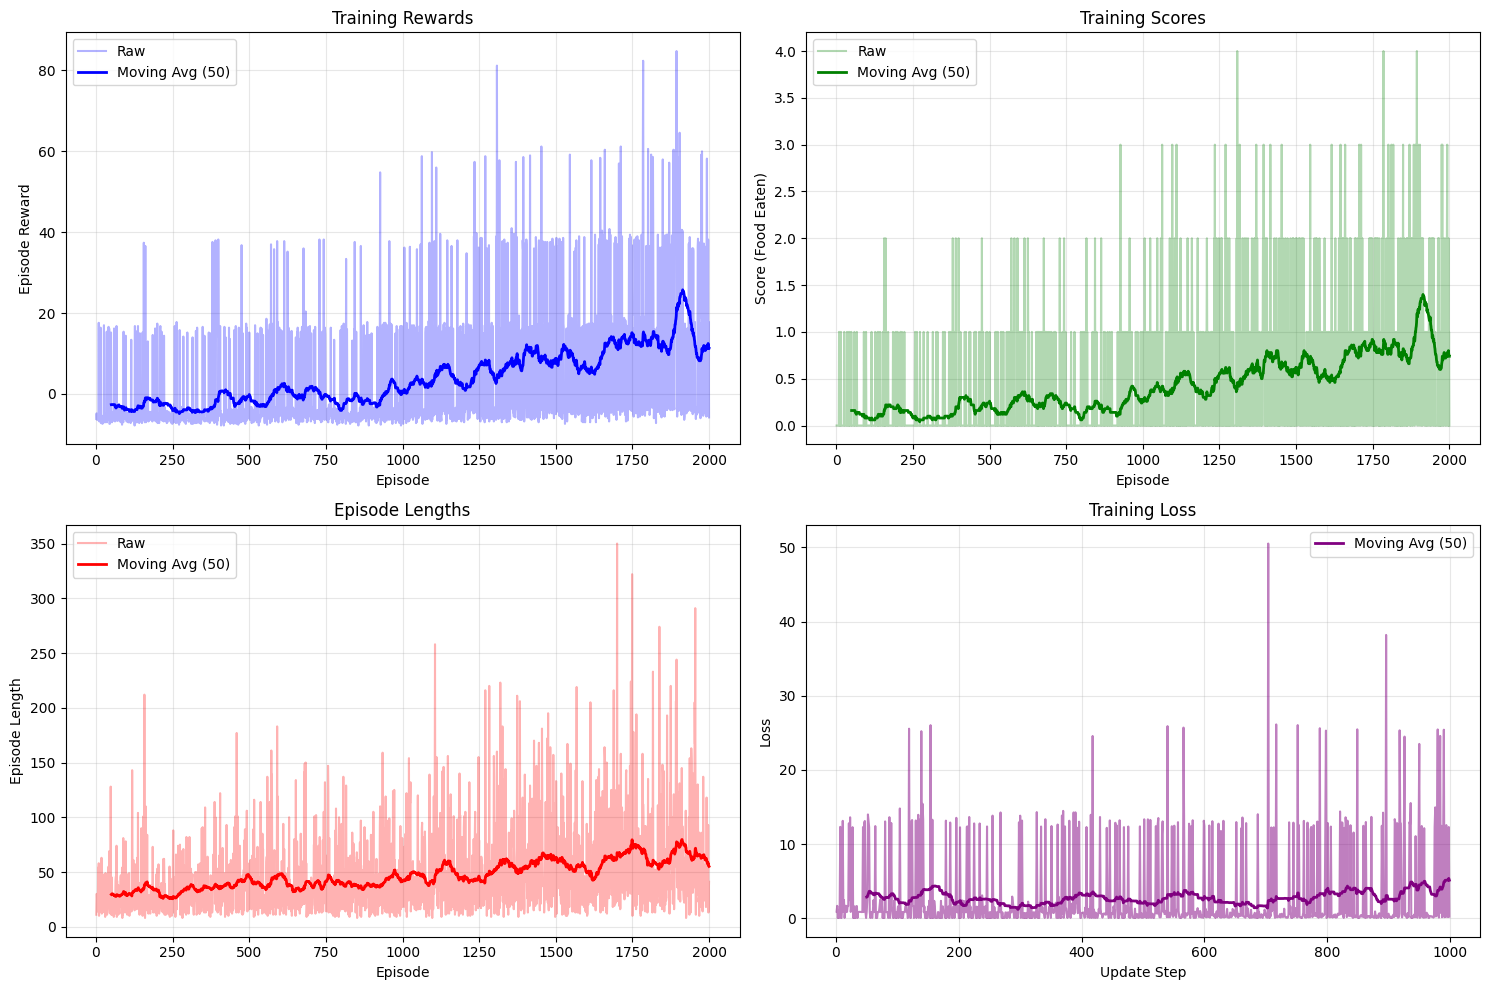

In [11]:
# Plot training curves
plot_training_curves(metrics_tracker, window=50)

## Step 11: Evaluate Trained Agent

In [12]:
# Evaluate trained agent
eval_results = evaluate_agent(env, agent, num_episodes=10, deterministic=True)

print("\n" + "="*50)
print("Final Evaluation Results")
print("="*50)
print(f"Mean Reward: {eval_results['mean_reward']:.2f} ± {eval_results['std_reward']:.2f}")
print(f"Max Reward: {eval_results['max_reward']:.2f}")
print(f"Mean Score: {eval_results['mean_score']:.2f} ± {eval_results['std_score']:.2f}")
print(f"Max Score: {eval_results['max_score']:.2f}")
print(f"Mean Length: {eval_results['mean_length']:.2f} ± {eval_results['std_length']:.2f}")
print("="*50)


Final Evaluation Results
Mean Reward: 11.06 ± 11.45
Max Reward: 24.40
Mean Score: 0.50 ± 0.50
Max Score: 1.00
Mean Length: 408.30 ± 125.10


## Step 12: Save Model to Google Drive

In [13]:
# # Save model to Google Drive
# if 'DRIVE_PATH' in globals():
#     import shutil

#     # Save final model
#     final_model_path = f'{DRIVE_PATH}/snake_final_model.pth'
#     agent.save(final_model_path)
#     print(f"✓ Final model saved to: {final_model_path}")

#     # Save metrics
#     metrics_path = f'{DRIVE_PATH}/metrics.json'
#     metrics_tracker.save(metrics_path)
#     print(f"✓ Metrics saved to: {metrics_path}")

#     # Copy best model if it exists
#     best_model_local = f'{PROJECT_DIR}/checkpoints/snake/best_model.pth'
#     if os.path.exists(best_model_local):
#         best_model_drive = f'{DRIVE_PATH}/snake_best_model.pth'
#         shutil.copy(best_model_local, best_model_drive)
#         print(f"✓ Best model copied to: {best_model_drive}")
# else:
#     print("Google Drive not mounted. Models saved locally.")
#     print(f"Note: Local files will be deleted when Colab session ends.")

## Step 13: Download Results (Optional)

If you didn't mount Google Drive, download the model files:

In [14]:
# # Download model files
# from google.colab import files

# # Download best model
# if os.path.exists(f'{PROJECT_DIR}/checkpoints/snake/best_model.pth'):
#     files.download(f'{PROJECT_DIR}/checkpoints/snake/best_model.pth')

# # Download metrics
# if os.path.exists(f'{PROJECT_DIR}/checkpoints/snake/metrics.json'):
#     files.download(f'{PROJECT_DIR}/checkpoints/snake/metrics.json')

KeyboardInterrupt: 

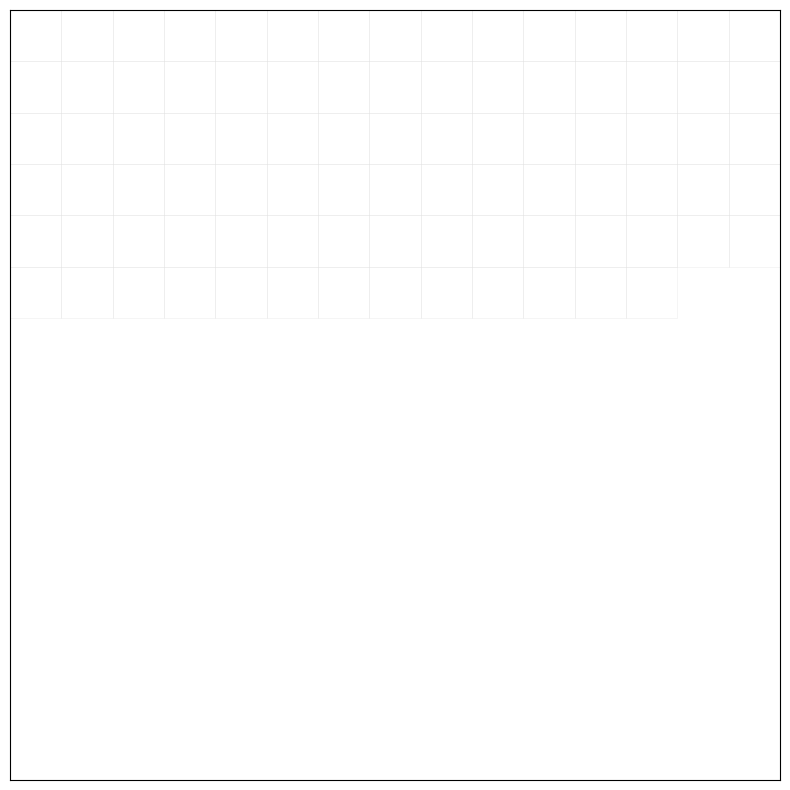

In [15]:
# Watch Trained Agent Play Snake - Complete Cell
# Fix imports for Colab
import sys
import os

# Add src to path
sys.path.insert(0, '/content/drl/src')

# Now the imports should work
from environments import SnakeEnv
from agents import DQNAgent, PPODiscreteAgent

import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import display, clear_output  # Both needed!
import time
import yaml

# Load config
config_path = '/content/drl/configs/snake_config.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

# Create environment
env = SnakeEnv(
    grid_size=config['environment']['grid_size'],
    state_representation=config['environment']['state_representation'],
    initial_length=config['environment']['initial_length'],
    reward_food=config['environment']['reward_food'],
    reward_death=config['environment']['reward_death'],
    reward_step=config['environment']['reward_step'],
    reward_distance=config['environment']['reward_distance'],
    render_mode=None
)

# Get state shape
obs_space = env.observation_space
state_shape = obs_space.shape if hasattr(obs_space, 'shape') else (obs_space.n,)

# Load trained agent
checkpoint_path = '/content/drl/checkpoints/snake/best_model.pth'  # Change if needed

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
algorithm = config['training']['algorithm'].lower()

if algorithm == "dqn":
    agent = DQNAgent(
        state_shape=state_shape,
        num_actions=env.action_space.n,
        learning_rate=config['dqn']['learning_rate'],
        gamma=config['dqn']['gamma'],
        epsilon_start=config['dqn']['epsilon_start'],
        epsilon_end=config['dqn']['epsilon_end'],
        epsilon_decay=config['dqn']['epsilon_decay'],
        replay_buffer_size=config['dqn']['replay_buffer_size'],
        batch_size=config['dqn']['batch_size'],
        target_update_frequency=config['dqn']['target_update_frequency'],
        hidden_sizes=config['dqn']['network'],
        activation=config['dqn']['activation'],
        state_representation=config['environment']['state_representation'],
        device=device
    )
else:
    agent = PPODiscreteAgent(
        state_shape=state_shape,
        num_actions=env.action_space.n,
        learning_rate=config['ppo']['learning_rate'],
        gamma=config['ppo']['gamma'],
        gae_lambda=config['ppo']['gae_lambda'],
        clip_epsilon=config['ppo']['clip_epsilon'],
        value_coef=config['ppo']['value_coef'],
        entropy_coef=config['ppo']['entropy_coef'],
        max_grad_norm=config['ppo']['max_grad_norm'],
        update_epochs=config['ppo']['update_epochs'],
        batch_size=config['ppo']['batch_size'],
        hidden_sizes=config['ppo']['network'],
        activation=config['ppo']['activation'],
        state_representation=config['environment']['state_representation'],
        device=device
    )

# Load checkpoint
agent.load(checkpoint_path)

# Set to evaluation mode (if method exists)
if hasattr(agent, 'eval'):
    agent.eval()
elif hasattr(agent, 'q_network'):
    agent.q_network.eval()

print(f"✅ Agent loaded from {checkpoint_path}")

# Watch agent play function
def watch_agent_play(env, agent, num_episodes=3, delay=0.1, max_steps=500):
    """Watch trained agent play Snake game."""

    for episode in range(num_episodes):
        state, info = env.reset()
        done = False
        steps = 0
        total_reward = 0

        print(f"\n{'='*50}")
        print(f"Episode {episode + 1}")
        print(f"{'='*50}")

        while not done and steps < max_steps:
            # Get action
            if isinstance(agent, DQNAgent):
                action = agent.act(state, deterministic=True)
            else:
                action, _, _ = agent.act(state, deterministic=True)

            # Take step
            next_state, reward, terminated, truncated, step_info = env.step(action)
            done = terminated or truncated

            total_reward += reward
            steps += 1
            state = next_state

            # Render
            fig, ax = plt.subplots(figsize=(10, 10))
            ax.set_xlim(0, env.grid_size)
            ax.set_ylim(0, env.grid_size)
            ax.set_aspect('equal')
            ax.invert_yaxis()
            ax.set_xticks([])
            ax.set_yticks([])

            # Draw grid
            for i in range(env.grid_size):
                for j in range(env.grid_size):
                    rect = plt.Rectangle((j, i), 1, 1,
                                       linewidth=0.5, edgecolor='lightgray',
                                       facecolor='white', alpha=0.3)
                    ax.add_patch(rect)

            # Draw snake
            for i, segment in enumerate(env.snake):
                row, col = segment
                if i == 0:
                    color = '#2E7D32'  # Head - dark green
                    alpha = 1.0
                else:
                    color = '#66BB6A'  # Body - light green
                    alpha = 0.8 - (i / len(env.snake)) * 0.3

                rect = plt.Rectangle((col, row), 1, 1,
                                   linewidth=1, edgecolor='darkgreen',
                                   facecolor=color, alpha=alpha)
                ax.add_patch(rect)

            # Draw food
            if env.food:
                row, col = env.food
                circle = plt.Circle((col + 0.5, row + 0.5), 0.4,
                                 color='red', alpha=0.8)
                ax.add_patch(circle)

            # Info text
            info_text = (f"Episode {episode + 1} | "
                        f"Score: {env.score} | "
                        f"Steps: {steps} | "
                        f"Length: {len(env.snake)} | "
                        f"Reward: {total_reward:.1f}")
            ax.text(0.5, -0.05, info_text,
                   transform=ax.transAxes, ha='center',
                   fontsize=12, fontweight='bold')

            ax.set_title('Snake Game - Trained Agent', fontsize=16, fontweight='bold')
            plt.tight_layout()

            display(fig)
            clear_output(wait=True)
            time.sleep(delay)
            plt.close(fig)

            if done:
                break

        print(f"\nEpisode {episode + 1} Complete!")
        print(f"  Final Score: {env.score}")
        print(f"  Total Steps: {steps}")
        print(f"  Total Reward: {total_reward:.2f}")
        print(f"  Snake Length: {len(env.snake)}")

    # Set back to training mode (if method exists)
    if hasattr(agent, 'train'):
        agent.train()
    elif hasattr(agent, 'q_network'):
        agent.q_network.train()

    print(f"\n{'='*50}")
    print("All episodes complete!")
    print(f"{'='*50}")

# Run it!
watch_agent_play(env, agent, num_episodes=3, delay=0.01)